In [7]:
# 1. ติดตั้งไลบรารี (หากยังไม่ได้ติดตั้งใน session นี้ ให้ uncomment บรรทัดล่างครับ)
!pip install -q xee geemap xarray shapely matplotlib pandas

กำลังประมวลผลข้อมูล Sentinel-2...


/usr/local/lib/python3.12/dist-packages/xee/ext.py:586: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


กำลังสร้างแผนที่ผลลัพธ์...


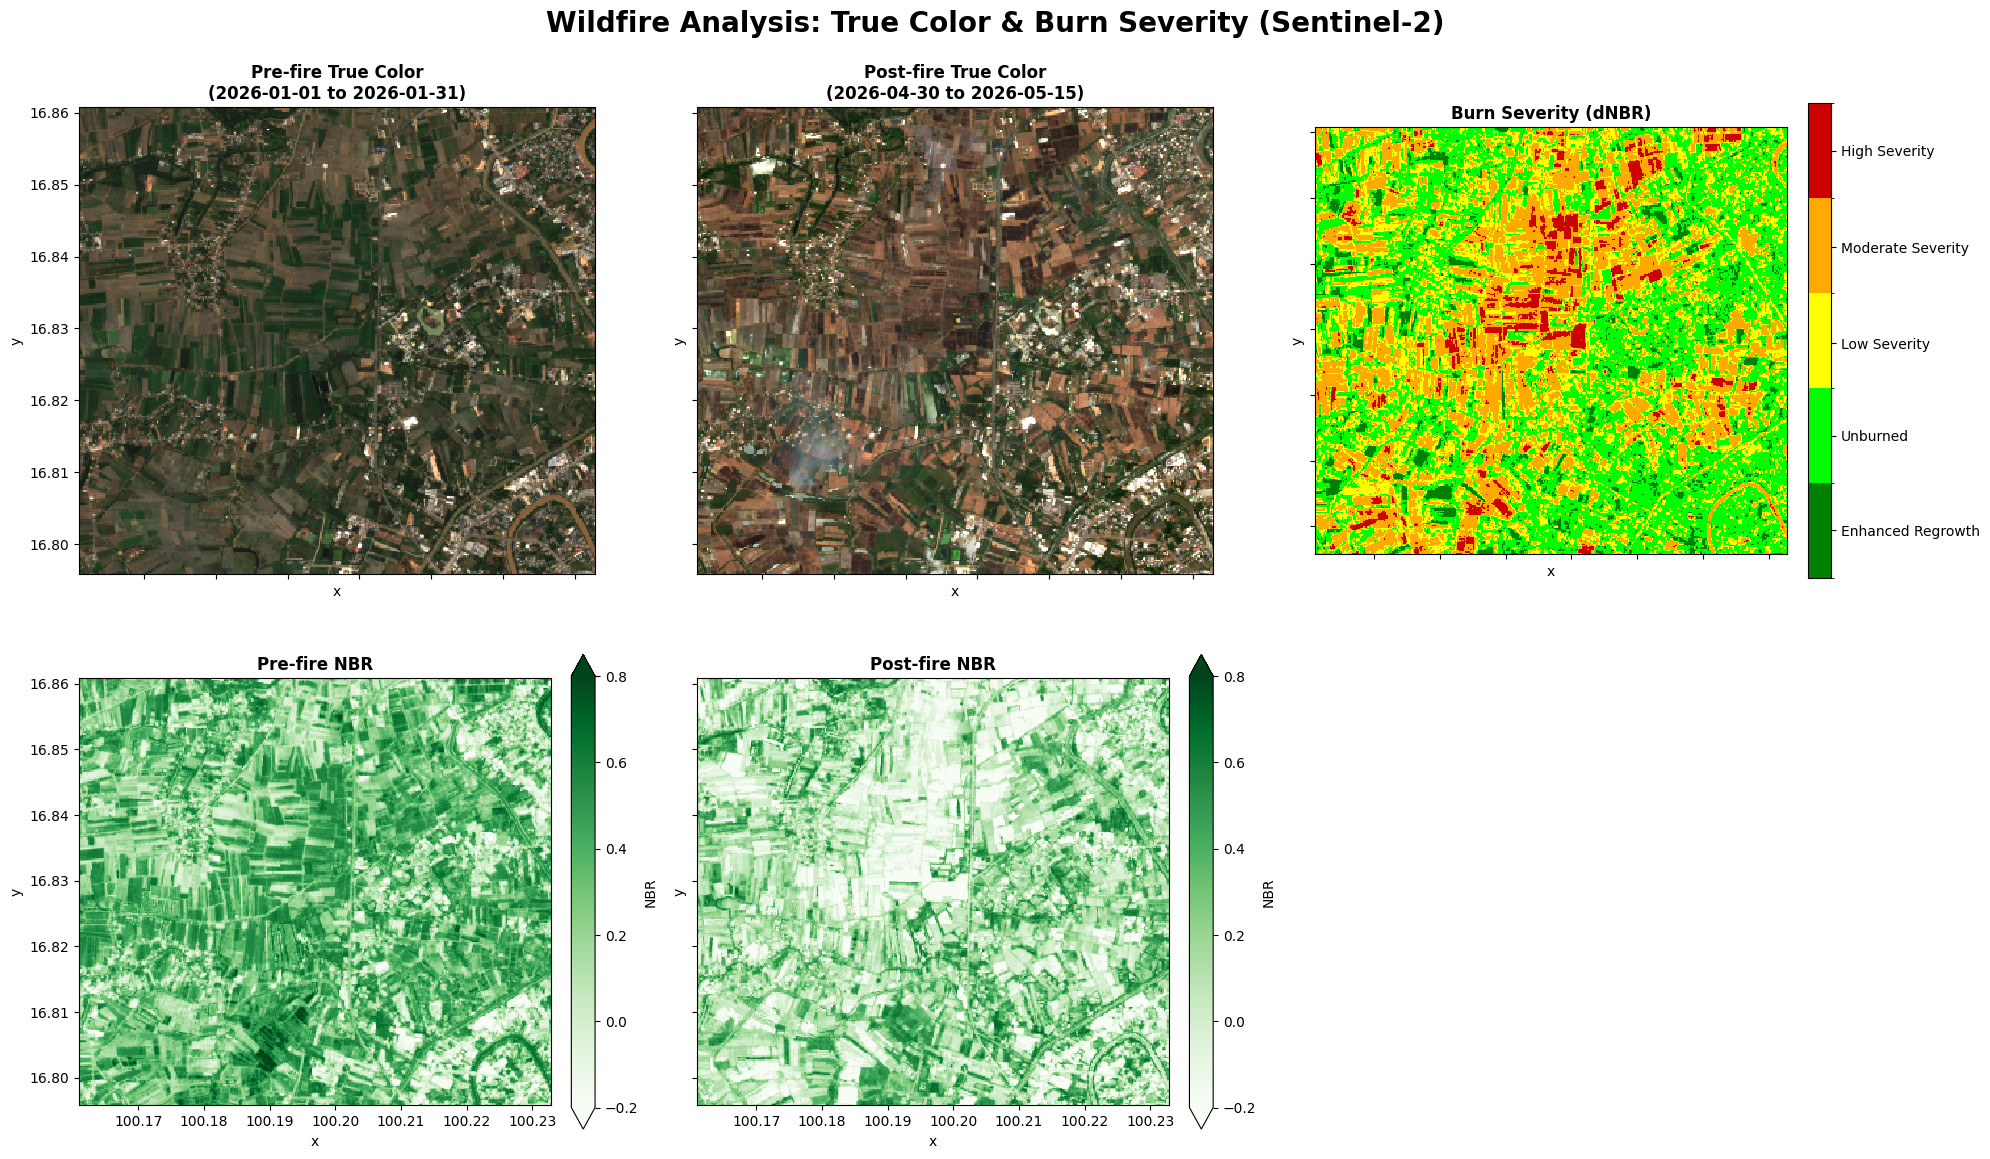

In [11]:
# ========================================================
# โค้ดวิเคราะห์ไฟป่าด้วย dNBR และภาพ True Color จาก Sentinel-2
# ========================================================
import ee
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import shapely
from xee import helpers
from matplotlib.colors import ListedColormap, BoundaryNorm

# 1. ยืนยันตัวตน GEE (ถ้ายังไม่ได้ทำ)
# ee.Authenticate() # หากรันไปแล้วสามารถคอมเมนต์บรรทัดนี้ได้
ee.Initialize(project='ee-end-to-end-gee')

# ========================================================
# 2. กำหนดพื้นที่ศึกษา (Phitsanulok Area) และช่วงเวลา
# ========================================================
min_lon, min_lat = 100.16119010692728, 16.795978728481742
max_lon, max_lat = 100.23270040751413, 16.860656792384646

roi_ee = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat])
aoi_shapely = shapely.geometry.box(min_lon, min_lat, max_lon, max_lat)

pre_start, pre_end = '2026-01-01', '2026-01-31'   # ก่อนไฟไหม้
post_start, post_end = '2026-04-30', '2026-05-15' # หลังไฟไหม้

# ========================================================
# 3. ดึงข้อมูล Sentinel-2 และคำนวณ NBR + True Color
# ========================================================
print("กำลังประมวลผลข้อมูล Sentinel-2...")

def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(qa.bitwiseAnd(cirrusBitMask).eq(0))
    # ปรับสเกลข้อมูลด้วยการหาร 10,000 (ค่าจะอยู่ในช่วง 0-1)
    return image.updateMask(mask).divide(10000).copyProperties(image, ["system:time_start"])

s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterBounds(roi_ee).map(mask_s2_clouds)

pre_img = s2.filterDate(pre_start, pre_end).median()
post_img = s2.filterDate(post_start, post_end).median()

# คำนวณ NBR
nbr_pre = pre_img.normalizedDifference(['B8', 'B12']).rename('NBR_PRE')
nbr_post = post_img.normalizedDifference(['B8', 'B12']).rename('NBR_POST')
dnbr = nbr_pre.subtract(nbr_post).rename('dNBR')

# --- ส่วนที่เพิ่มเข้ามา: ดึงภาพ True Color (B4=Red, B3=Green, B2=Blue) ---
# ต้อง rename เพื่อไม่ให้ชื่อแบนด์ตีกันเมื่อรวมเข้า xarray
pre_rgb = pre_img.select(['B4', 'B3', 'B2']).rename(['R_PRE', 'G_PRE', 'B_PRE'])
post_rgb = post_img.select(['B4', 'B3', 'B2']).rename(['R_POST', 'G_POST', 'B_POST'])

# รวมแบนด์ทั้งหมด (NBR, dNBR, True Color ก่อนและหลัง)
combined = ee.Image.cat([nbr_pre, nbr_post, dnbr, pre_rgb, post_rgb])

# ========================================================
# 4. ดึงข้อมูลเข้าสู่ Xarray
# ========================================================
grid_params = helpers.fit_geometry(
    geometry=aoi_shapely,
    grid_crs='EPSG:4326',
    grid_scale=(0.0002, -0.0002)
)

ds = xr.open_dataset(
    ee.ImageCollection([combined]),
    engine='ee',
    **grid_params
).squeeze()

# ========================================================
# 5. พล็อตแผนที่ผลลัพธ์ (ฉบับปรับแก้ขนาดกรอบให้เท่ากัน)
# ========================================================
print("กำลังสร้างแผนที่ผลลัพธ์...")

# 1. เพิ่ม sharex=True และ sharey=True เพื่อบังคับให้ทุกภาพแชร์แกนเดียวกัน
fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=True)

# พารามิเตอร์วิเศษสำหรับ Colorbar เพื่อไม่ให้มันไปบีบกราฟหลัก
cbar_settings = {'fraction': 0.046, 'pad': 0.04}

# ----------------- แถวที่ 1 -----------------
# ภาพที่ 1: Pre-fire True Color
ds[['R_PRE', 'G_PRE', 'B_PRE']].to_array().plot.imshow(ax=axes[0, 0], vmin=0, vmax=0.3)
axes[0, 0].set_title(f'Pre-fire True Color\n({pre_start} to {pre_end})', fontweight='bold')

# ภาพที่ 2: Post-fire True Color
ds[['R_POST', 'G_POST', 'B_POST']].to_array().plot.imshow(ax=axes[0, 1], vmin=0, vmax=0.3)
axes[0, 1].set_title(f'Post-fire True Color\n({post_start} to {post_end})', fontweight='bold')

# ภาพที่ 3: Burn Severity (dNBR)
cmap = ListedColormap(['#008000', '#00fc00', '#ffff00', '#ffaa00', '#ff0000', '#cc0000'])
bounds = [-0.5, -0.1, 0.1, 0.27, 0.66, 1.3]
norm = BoundaryNorm(bounds, cmap.N)

p = ds.dNBR.plot(ax=axes[0, 2], cmap=cmap, norm=norm, add_colorbar=False)
axes[0, 2].set_title('Burn Severity (dNBR)', fontweight='bold')

# 2. เพิ่ม fraction และ pad ให้ Colorbar แยก
cbar = fig.colorbar(p, ax=axes[0, 2], boundaries=bounds, ticks=[-0.3, 0, 0.18, 0.46, 0.98], **cbar_settings)
cbar.ax.set_yticklabels(['Enhanced Regrowth', 'Unburned', 'Low Severity', 'Moderate Severity', 'High Severity'])


# ----------------- แถวที่ 2 -----------------
# 3. เพิ่ม cbar_kwargs ให้ภาพ NBR
ds.NBR_PRE.plot(ax=axes[1, 0], cmap='Greens', vmin=-0.2, vmax=0.8,
                cbar_kwargs={'label': 'NBR', **cbar_settings})
axes[1, 0].set_title('Pre-fire NBR', fontweight='bold')

ds.NBR_POST.plot(ax=axes[1, 1], cmap='Greens', vmin=-0.2, vmax=0.8,
                 cbar_kwargs={'label': 'NBR', **cbar_settings})
axes[1, 1].set_title('Post-fire NBR', fontweight='bold')

# ซ่อนกราฟช่องสุดท้าย
axes[1, 2].axis('off')

# 4. ล็อคสัดส่วน x, y ให้สมมาตร (1:1) ทุกๆ กราฟ เพื่อไม่ให้ภาพยืด
for ax in axes.flatten():
    if ax.has_data(): # เช็คว่ากราฟไม่ได้ถูกซ่อน (ข้ามช่องที่ว่างไป)
        ax.set_aspect('equal', adjustable='box')

plt.suptitle('Wildfire Analysis: True Color & Burn Severity (Sentinel-2)', y=0.98, fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()